In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
url = "https://raw.githubusercontent.com/shubhratodkar2112-cpu/CodeAlpha_IrisClassification/main/Iris.csv"

df = pd.read_csv(url)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (150, 6)

Column Names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

Data Types:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

Missing Values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [4]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [5]:
print("Number of samples for each species:")
print(df["Species"].value_counts())

Number of samples for each species:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


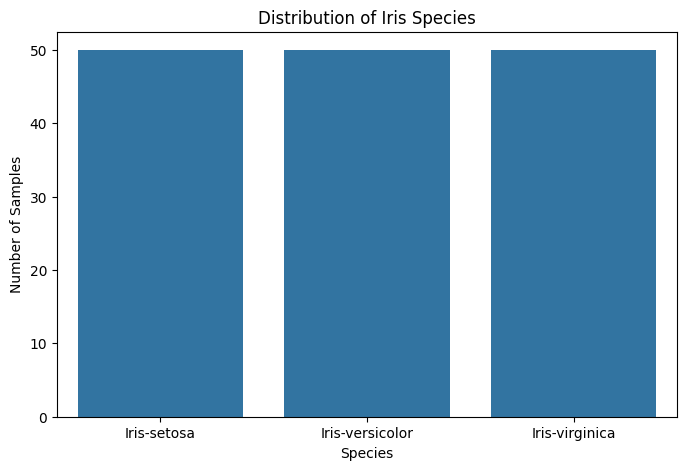

In [6]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Species")

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.show()

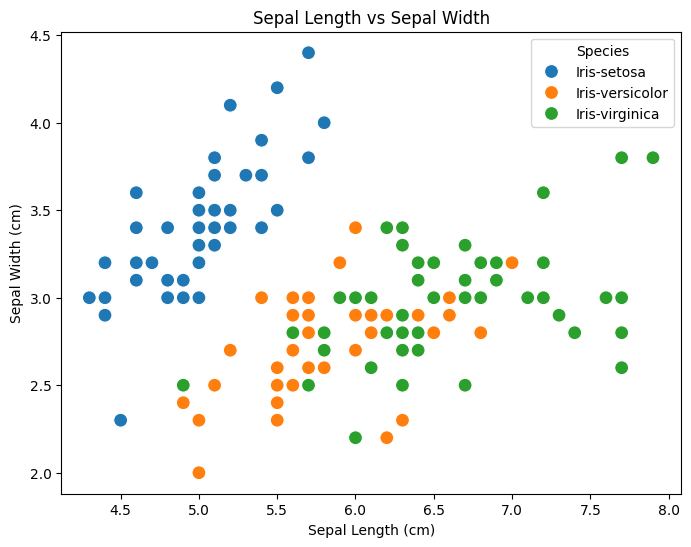

In [7]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="SepalLengthCm",
    y="SepalWidthCm",
    hue="Species",
    s=100
)

plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")

plt.show()

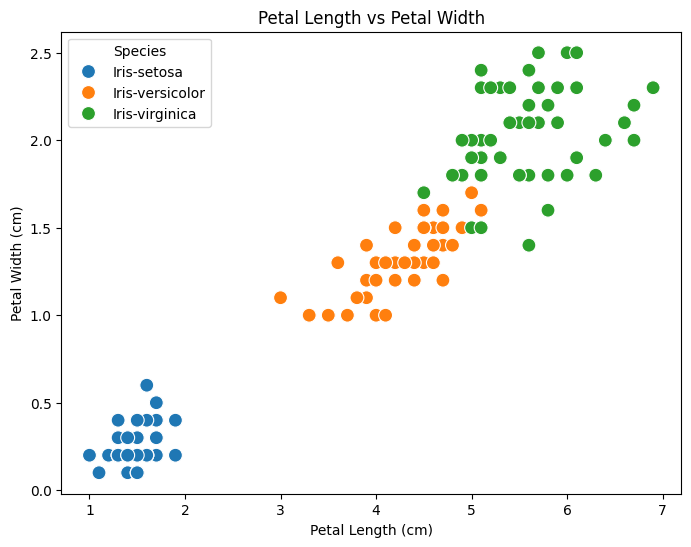

In [8]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species",
    s=100
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")

plt.show()

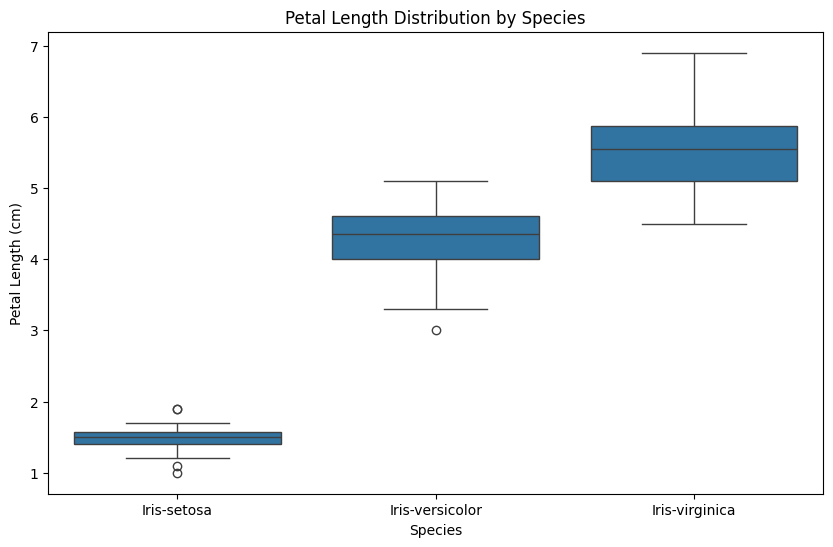

In [10]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Species",
    y="PetalLengthCm"
)

plt.title("Petal Length Distribution by Species")
plt.xlabel("Species")
plt.ylabel("Petal Length (cm)")

plt.show()

In [11]:
# Select input features
X = df[[
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]]

# Select target variable
y = df["Species"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [14]:
# Make predictions on the test data
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']


In [15]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.9666666666666667
Accuracy Percentage: 96.66666666666667 %


In [16]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



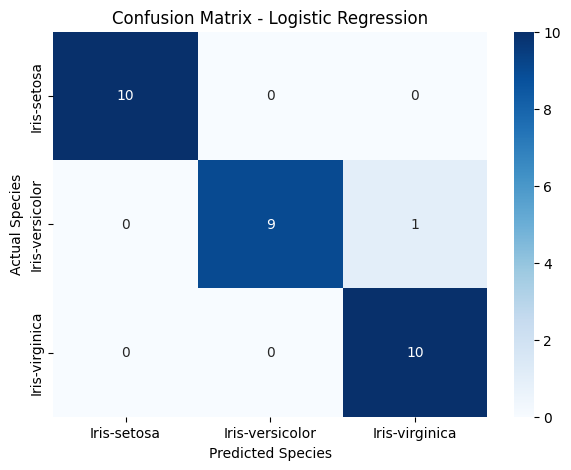

In [17]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.show()

In [18]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Accuracy (%):", dt_accuracy * 100)

Decision Tree Accuracy: 0.9333333333333333
Decision Tree Accuracy (%): 93.33333333333333


In [19]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest Accuracy (%):", rf_accuracy * 100)

Random Forest Accuracy: 0.9
Random Forest Accuracy (%): 90.0


In [21]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_accuracy)
print("KNN Accuracy (%):", knn_accuracy * 100)

KNN Accuracy: 1.0
KNN Accuracy (%): 100.0


In [22]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "K-Nearest Neighbors"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy
    ]
})

results["Accuracy (%)"] = results["Accuracy"] * 100

results

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.966667,96.666667
1,Decision Tree,0.933333,93.333333
2,Random Forest,0.900000,90.000000
3,K-Nearest Neighbors,1.000000,100.000000


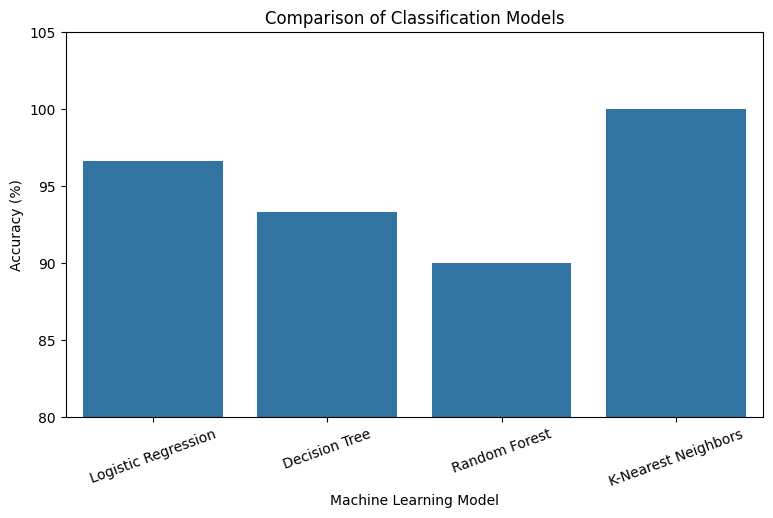

In [23]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy (%)"
)

plt.title("Comparison of Classification Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(80, 105)
plt.xticks(rotation=20)

plt.show()

In [24]:
print("KNN Classification Report:")
print(classification_report(y_test, knn_pred))

KNN Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



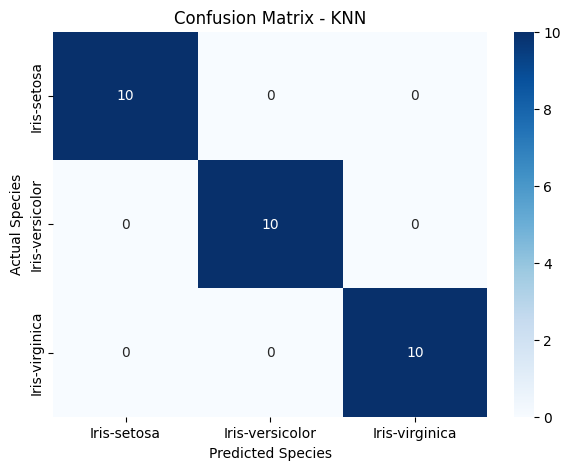

In [25]:
knn_cm = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=knn_model.classes_,
    yticklabels=knn_model.classes_
)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.show()

In [27]:
new_flower = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=[
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
)

prediction = knn_model.predict(new_flower)

print("Predicted Species:", prediction[0])

Predicted Species: Iris-setosa


In [28]:
results

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.966667,96.666667
1,Decision Tree,0.933333,93.333333
2,Random Forest,0.900000,90.000000
3,K-Nearest Neighbors,1.000000,100.000000


# 🌸 Iris Flower Classification Using Machine Learning

## CodeAlpha Data Science Internship — Task 1

### 📌 Project Objective

The objective of this project is to build a machine learning classification model that can identify the species of an Iris flower based on its sepal and petal measurements.

### 📊 Dataset

The Iris dataset contains 150 samples belonging to three species:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The dataset contains four main features:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

### 🛠️ Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

### 🤖 Machine Learning Models

The following classification algorithms were evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors

### 🎯 Project Workflow

Data Loading → Data Exploration → Data Visualization → Train-Test Split → Model Training → Model Evaluation → Model Comparison → Prediction

# Conclusion

This project successfully classified Iris flowers into three species: Iris-setosa, Iris-versicolor, and Iris-virginica using machine learning.

The dataset contained 150 samples and four main measurement features: sepal length, sepal width, petal length, and petal width. Exploratory Data Analysis showed that petal measurements provide strong separation between the three species.

Four classification models were evaluated:

- Logistic Regression — 96.67% accuracy
- Decision Tree — 93.33% accuracy
- Random Forest — 90.00% accuracy
- K-Nearest Neighbors — 100.00% accuracy

Among the evaluated models, K-Nearest Neighbors achieved the highest accuracy of 100% on the test dataset and was selected as the final model.

The final model was also tested with a new flower's measurements and successfully predicted its species as Iris-setosa.

This project demonstrates the complete basic machine learning workflow, including data exploration, visualization, model training, evaluation, model comparison, and prediction.